In [90]:
# Install the package if not already installed
# !pip install -e .

# Import the main package
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Import the DSF analysis package
from dsf_analysis import (
    # Core functions
    load_data_with_derivative_boltzmann,
    analyze_dsf_data,
    
    # Model fitting functions
    select_best_model_for_trace,
    get_negative_control_fit,
    
    # Visualization functions
    plot_model_fit,
    plot_reps_and_neg_control,
    create_interactive_heatmap,
    
    # Utility functions
    load_uniprot_mapping,
    load_smiles_mapping,
    create_output_directory,
    clear_caches
)

# Try to import SMILES visualization functions
try:
    from dsf_analysis.visualization.smiles import (
        plot_dsf_curve_with_structure,
        create_structure_grid
    )
    SMILES_AVAILABLE = True
except ImportError:
    SMILES_AVAILABLE = False
    print("RDKit not available. Chemical structure visualization will be disabled.")

# Set up paths to example data
DATA_DIR = "./examples/data"
PLATE_MAP_DIR = "./examples/plate_maps"
MAPPINGS_DIR = "./examples/mappings"
OUTPUT_DIR = "./output"

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

## Basic Usage Example

Let's start with a basic example of loading and analyzing DSF data. This example demonstrates the core functionality without using advanced features like UniProt mapping or SMILES visualization.

In [91]:


# Load the data
raw_data_dfs, derivative_data_dfs, boltzmann_data_dfs, plate_map_dict = load_data_with_derivative_boltzmann(
    parent_folder=DATA_DIR,
    plate_map_folder=PLATE_MAP_DIR
)

# Print summary of loaded data
print("Loaded data for the following proteins:")
for protein in raw_data_dfs:
    print(f"  {protein}:")
    for plate in raw_data_dfs[protein]:
        print(f"    {plate}: {len(raw_data_dfs[protein][plate])} replicates")
        for rep in raw_data_dfs[protein][plate]:
            print(f"      {rep}: {len(raw_data_dfs[protein][plate][rep])} wells")

print("\nLoaded plate maps:")
for plate_id, plate_df in plate_map_dict.items():
    print(f"  {plate_id}: {len(plate_df)} wells")

Loaded data for the following proteins:
  B9:
    PM1: 2 replicates
      Rep02: 96 wells
      Rep01: 96 wells

Loaded plate maps:
  PM4: 96 wells
  PM2: 96 wells
  PM3: 96 wells
  PM5: 96 wells
  PM1: 96 wells


In [92]:


# Run a basic analysis
basic_output_dir = os.path.join(OUTPUT_DIR, "basic_analysis")

raw_data_dfs, master_df, output_dir = analyze_dsf_data(
    parent_folder=DATA_DIR,
    plate_map_folder=PLATE_MAP_DIR,
    output_dir=basic_output_dir,
    candidate_models=["mB"],  # Use modified Boltzmann
    window_mode="full",
    window_sizes=[20, 30, 40],
    neg_control_well="A01"  # Assuming A01 is the negative control
)

# Display the results summary
print(f"Analysis complete. Results saved to {output_dir}")
print(f"Master dataframe has {len(master_df)} rows")

# Show the first few rows of the master dataframe
master_df.head()

Loading data from ./examples/data...
Loaded data for 1 proteins
Processing B9, PM1...
Processing B9, PM1, Rep02, A02


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Processing B9, PM1, Rep02, A03
Processing B9, PM1, Rep02, A04
Processing B9, PM1, Rep02, A05
Processing B9, PM1, Rep02, A06
Processing B9, PM1, Rep02, A07
Processing B9, PM1, Rep02, A08
Processing B9, PM1, Rep02, A09
Processing B9, PM1, Rep02, A10
Processing B9, PM1, Rep02, A11
Processing B9, PM1, Rep02, A12
Processing B9, PM1, Rep02, B01
Processing B9, PM1, Rep02, B02
Processing B9, PM1, Rep02, B03
Processing B9, PM1, Rep02, B04
Processing B9, PM1, Rep02, B05
Processing B9, PM1, Rep02, B06
Processing B9, PM1, Rep02, B07
Processing B9, PM1, Rep02, B08
Processing B9, PM1, Rep02, B09
Processing B9, PM1, Rep02, B10
Processing B9, PM1, Rep02, B11
Processing B9, PM1, Rep02, B12
Processing B9, PM1, Rep02, C01
Processing B9, PM1, Rep02, C02
Processing B9, PM1, Rep02, C03
Processing B9, PM1, Rep02, C04
Processing B9, PM1, Rep02, C05
Processing B9, PM1, Rep02, C06
Processing B9, PM1, Rep02, C07


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Processing B9, PM1, Rep02, C08
Processing B9, PM1, Rep02, C09
Processing B9, PM1, Rep02, C10
Processing B9, PM1, Rep02, C11
Processing B9, PM1, Rep02, C12
Processing B9, PM1, Rep02, D01
Processing B9, PM1, Rep02, D02
Processing B9, PM1, Rep02, D03
Processing B9, PM1, Rep02, D04
Processing B9, PM1, Rep02, D05
Processing B9, PM1, Rep02, D06
Processing B9, PM1, Rep02, D07
Processing B9, PM1, Rep02, D08
Processing B9, PM1, Rep02, D09
Processing B9, PM1, Rep02, D10
Processing B9, PM1, Rep02, D11
Processing B9, PM1, Rep02, D12
Processing B9, PM1, Rep02, E01
Processing B9, PM1, Rep02, E02
Processing B9, PM1, Rep02, E03
Processing B9, PM1, Rep02, E04
Processing B9, PM1, Rep02, E05
Processing B9, PM1, Rep02, E06
Processing B9, PM1, Rep02, E07
Processing B9, PM1, Rep02, E08
Processing B9, PM1, Rep02, E09
Processing B9, PM1, Rep02, E10
Processing B9, PM1, Rep02, E11
Processing B9, PM1, Rep02, E12
Processing B9, PM1, Rep02, F01
Processing B9, PM1, Rep02, F02
Processing B9, PM1, Rep02, F03
Processi

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Processing B9, PM1, Rep02, H09
Processing B9, PM1, Rep02, H10
Processing B9, PM1, Rep02, H11
Processing B9, PM1, Rep02, H12
Processing B9, PM1, Rep01, A02
Processing B9, PM1, Rep01, A03
Processing B9, PM1, Rep01, A04
Processing B9, PM1, Rep01, A05
Processing B9, PM1, Rep01, A06
Processing B9, PM1, Rep01, A07
Processing B9, PM1, Rep01, A08
Processing B9, PM1, Rep01, A09
Processing B9, PM1, Rep01, A10
Processing B9, PM1, Rep01, A11
Processing B9, PM1, Rep01, A12
Processing B9, PM1, Rep01, B01
Processing B9, PM1, Rep01, B02
Processing B9, PM1, Rep01, B03
Processing B9, PM1, Rep01, B04
Processing B9, PM1, Rep01, B05
Processing B9, PM1, Rep01, B06
Processing B9, PM1, Rep01, B07
Processing B9, PM1, Rep01, B08
Processing B9, PM1, Rep01, B09
Processing B9, PM1, Rep01, B10
Processing B9, PM1, Rep01, B11
Processing B9, PM1, Rep01, B12
Processing B9, PM1, Rep01, C01
Processing B9, PM1, Rep01, C02
Processing B9, PM1, Rep01, C03
Processing B9, PM1, Rep01, C04
Processing B9, PM1, Rep01, C05
Processi

,model,window_size,t_start,t_end,popt,R2,Tm1,protein,plate_ID,rep,well,ligand,Tm_D,Tm1_neg,dTm1,Tm_D_neg,dTm_D
0,mB,None,25.0016,94.9409,"[-0.9905287539954046, 0.2833334864499431, -0.5...",0.996977,56.557070,B9,PM1,Rep02,A02,L-Arabinose,57.542805,75.417665,-18.860595,57.542805,0.000000
1,mB,None,25.0016,94.9409,"[-1.307143254452179, 0.3418104080706972, -0.42...",0.991948,56.762209,B9,PM1,Rep02,A03,N-Acetyl-D-Glucosamine,58.028492,75.417665,-18.655456,57.542805,0.485687
2,mB,None,25.0016,94.9409,"[-1.1338029058993728, 0.32215897078736083, -0....",0.995677,57.061514,B9,PM1,Rep02,A04,D-Saccharic Acid,57.542805,75.417665,-18.356151,57.542805,0.000000
3,mB,None,25.0016,94.9409,"[-1.0657141611288121, 0.29163327931367505, -0....",0.996652,57.411304,B9,PM1,Rep02,A05,Succinic Acid,57.542805,75.417665,-18.006361,57.542805,0.000000
4,mB,None,25.0016,94.9409,"[-1.0232094414849437, 0.2940668319619742, -0.4...",0.993853,56.943560,B9,PM1,Rep02,A06,D-Galactose,58.514183,75.417665,-18.474104,57.542805,0.971378


## Advanced Usage with UniProt and SMILES Mappings

Now let's explore a more advanced example that includes UniProt ID mapping for proteins and SMILES code visualization for compounds.

In [ ]:
# # Load UniProt mapping
# uniprot_mapping_file = os.path.join(MAPPINGS_DIR, "uniprot_mapping.csv")
# uniprot_mapping = load_uniprot_mapping(uniprot_mapping_file)
# print(f"Loaded {len(uniprot_mapping)} UniProt mappings:")
# for protein, uniprot in uniprot_mapping.items():
#     print(f"  {protein} -> {uniprot}")

# # Load SMILES mapping
# smiles_mapping_file = os.path.join(MAPPINGS_DIR, "smiles_mapping.csv")
# smiles_mapping = load_smiles_mapping(smiles_mapping_file)
# print(f"\nLoaded {len(smiles_mapping)} SMILES mappings")
# print("First 3 compounds:")
# for i, (compound, smiles) in enumerate(smiles_mapping.items()):
#     if i < 3:
#         print(f"  {compound} -> {smiles}")

In [ ]:
# # Run advanced analysis with UniProt and SMILES integration
# advanced_output_dir = os.path.join(OUTPUT_DIR, "advanced_analysis")

# raw_data_dfs, master_df, output_dir = analyze_dsf_data(
#     parent_folder=DATA_DIR,
#     plate_map_folder=PLATE_MAP_DIR,
#     output_dir=advanced_output_dir,
#     candidate_models=["mB", "s1"],
#     window_mode="optimized",
#     window_sizes=[20, 30, 40],
#     neg_control_well="A01",
#     use_uniprot=True,
#     uniprot_mapping=uniprot_mapping_file,
#     use_smiles=True,
#     smiles_mapping=smiles_mapping_file
# )

# # Display the results summary
# print(f"Advanced analysis complete. Results saved to {output_dir}")
# print(f"Master dataframe has {len(master_df)} rows")

# # Show the first few rows of the master dataframe
# master_df.head()

## Model Fitting Examples

Let's explore how to fit models to DSF data. We'll focus on the modified Boltzmann (mB) model as requested, but also show other available models for comparison.

In [ ]:
# # Get a sample trace to work with
# protein = list(raw_data_dfs.keys())[0]
# plate = list(raw_data_dfs[protein].keys())[0]
# rep = list(raw_data_dfs[protein][plate].keys())[0]

# # Find a treatment well (not A01)
# treatment_well = None
# for well in raw_data_dfs[protein][plate][rep]:
#     if well != "A01":  # Skip negative control
#         treatment_well = well
#         break

# print(f"Selected sample: Protein {protein}, Plate {plate}, Replicate {rep}, Well {treatment_well}")

# # Get the raw data for this well
# df_raw = raw_data_dfs[protein][plate][rep][treatment_well]

# # Plot the raw data
# plt.figure(figsize=(10, 6))
# plt.plot(df_raw["Temperature"], df_raw["Fluorescence"], 'o-', color="black", alpha=0.7)
# plt.xlabel("Temperature (°C)")
# plt.ylabel("Fluorescence (RFU)")
# plt.title(f"Raw DSF Data: {protein}, {plate}, {rep}, {treatment_well}")
# plt.grid(True)
# plt.show()

In [ ]:
# # Fit the modified Boltzmann model
# best_fit_mB, summary_df_mB = select_best_model_for_trace(
#     df_raw=df_raw,
#     candidate_models=["mB"],  # Only use modified Boltzmann model
#     window_mode="optimized",
#     window_sizes=[20, 30, 40],
#     verbose=True,
#     protein=protein,
#     plate_ID=plate,
#     rep=rep,
#     well=treatment_well
# )

# # Plot the fit
# fig_mB = plot_model_fit(df_raw, best_fit_mB, title=f"Modified Boltzmann Model Fit: {protein}, {plate}, {treatment_well}")
# plt.show()

# # Print the fit parameters
# print("Modified Boltzmann Model Fit Results:")
# for key, value in best_fit_mB.items():
#     if key != "popt":  # Skip printing the parameters array
#         print(f"  {key}: {value}")

In [ ]:
# # Compare different models
# best_fit_all, summary_df_all = select_best_model_for_trace(
#     df_raw=df_raw,
#     candidate_models=["mB", "s1", "s2"],  # Try multiple models
#     window_mode="optimized",
#     window_sizes=[30],  # Use a fixed window size for simplicity
#     verbose=True,
#     protein=protein,
#     plate_ID=plate,
#     rep=rep,
#     well=treatment_well
# )

# # Display summary of all models
# print("\nModel Comparison:")
# print(summary_df_all[["model", "window_size", "R2", "Tm1"]].to_string(index=False))

# # Plot the best fit
# fig_best = plot_model_fit(df_raw, best_fit_all, title=f"Best Model Fit: {protein}, {plate}, {treatment_well}")
# plt.show()

## Specific Plotting Examples

Now let's explore various ways to visualize the DSF data and analysis results.

In [56]:
# Get a sample trace to work with
protein = list(raw_data_dfs.keys())[0]
plate = list(raw_data_dfs[protein].keys())[0]
rep = list(raw_data_dfs[protein][plate].keys())[0]

# Find a treatment well (not A01)
treatment_well = None
for well in raw_data_dfs[protein][plate][rep]:
    if well != "A01":  # Skip negative control
        treatment_well = well
        break

print(f"Selected sample: Protein {protein}, Plate {plate}, Replicate {rep}, Well {treatment_well}")

# Get the raw data for this well
df_raw = raw_data_dfs[protein][plate][rep][treatment_well]

Selected sample: Protein B9, Plate PM1, Replicate Rep01, Well A02


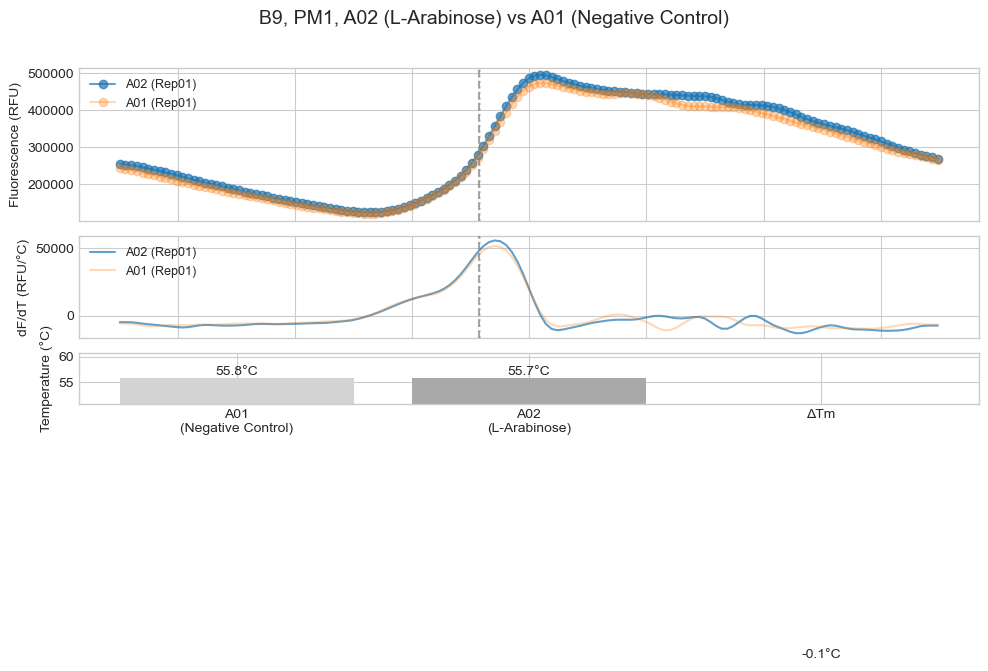

In [57]:
# Plot with negative control comparison
fig_with_neg = plot_reps_and_neg_control(
    protein=protein,
    plate=plate,
    treatment_well=treatment_well,
    neg_control_well="A01",
    raw_data_dfs=raw_data_dfs,
    candidate_models=["mB"],
    window_mode="full",
    window_sizes=[20, 30, 40],
    include_tmchange_subplot=True
)
plt.show()

In [100]:
def plot_replicates_with_comparison(
    protein, plate, treatment_well, neg_control_well="A01",
    raw_data_dfs=None, candidate_models=None,
    window_mode="optimized", window_sizes=[20, 30, 40, 50, 60, 70],
    fixed_window_size=20, verbose=True,
    include_tmchange_subplot=True,
    include_norm_subplot=False,
    save_png=True, png_filename=None, dTm_threshold=2,
    separate_rep_figures=True,
    skip_fit=False, 
    save_metadata_csv=False,  # <--- NEW
    metadata_csv_filename="metadata.csv"  # <--- NEW
):
    import os
    if candidate_models is None:
        candidate_models = list(MODEL_PARAMS.keys())

    model_desc = {
        "s1": "Single Sigmoidal",
        "s1_d": "Single Sigmoidal w/Decay",
        "s2": "Double Sigmoidal",
        "s2_d": "Double Sigmoidal w/Decay",
        "mB": "Modified Boltz."
    }

    reps = list(raw_data_dfs[protein][plate].keys())
    if verbose:
        print(f"Found replicates for {protein} {plate}: {reps}")

    metadata_records = []
    neg_control_fits = {}

    if separate_rep_figures:
        for i, rep in enumerate(reps):
            rep_data = raw_data_dfs[protein][plate][rep]
            if treatment_well not in rep_data or neg_control_well not in rep_data:
                if verbose:
                    print(f"{rep}: Missing required wells. Skipping.")
                continue

            df_treat = rep_data[treatment_well]
            df_neg = rep_data[neg_control_well]

            ligand_treat = get_ligand_for_plate_well(raw_data_dfs, plate, treatment_well)
            ligand_neg = get_ligand_for_plate_well(raw_data_dfs, plate, neg_control_well)

            if not skip_fit:
                if rep in neg_control_fits:
                    best_fit_neg = neg_control_fits[rep]
                else:
                    from dsf_analysis.core.models import select_best_model_for_trace
                    best_fit_neg, _ = select_best_model_for_trace(
                        df_neg, candidate_models=candidate_models,
                        window_mode=window_mode, window_sizes=window_sizes,
                        show_plot=False, protein=protein, ligand=ligand_neg,
                        rep=rep, plate_ID=plate, well=neg_control_well,
                        fixed_window_size=fixed_window_size
                    )
                    neg_control_fits[rep] = best_fit_neg

                best_fit_t, _ = select_best_model_for_trace(
                    df_treat, candidate_models=candidate_models,
                    window_mode=window_mode, window_sizes=window_sizes,
                    show_plot=False, protein=protein, ligand=ligand_treat,
                    rep=rep, plate_ID=plate, well=treatment_well,
                    fixed_window_size=fixed_window_size
                )
            else:
                best_fit_t = None
                best_fit_neg = None

            

            # Set up subplot layout as before.
            if include_tmchange_subplot and include_norm_subplot:
                nrows = 5
                height_ratios = [1, 3, 3, 1, 1]
                fig, axs = plt.subplots(nrows, 1, figsize=(10, 14), sharex=True,
                                        gridspec_kw={'height_ratios': height_ratios})
                ax_tmchange, ax_main, ax_norm, ax_deriv, ax_deriv_norm = axs
            elif include_tmchange_subplot and not include_norm_subplot:
                nrows = 3
                height_ratios = [1, 3, 1]
                fig, axs = plt.subplots(nrows, 1, figsize=(10, 10), sharex=True,
                                        gridspec_kw={'height_ratios': height_ratios})
                ax_tmchange, ax_main, ax_deriv = axs
            elif not include_tmchange_subplot and include_norm_subplot:
                nrows = 4
                height_ratios = [3, 3, 1, 1]
                fig, axs = plt.subplots(nrows, 1, figsize=(10, 12), sharex=True,
                                        gridspec_kw={'height_ratios': height_ratios})
                ax_main, ax_norm, ax_deriv, ax_deriv_norm = axs
            else:
                nrows = 2
                height_ratios = [3, 1]
                fig, axs = plt.subplots(nrows, 1, figsize=(10, 8), sharex=True,
                                        gridspec_kw={'height_ratios': height_ratios})
                ax_main, ax_deriv = axs

            rep_color = ["#0072B2", "#E69F00", "#009E73",
                         "#F0E442", "#56B4E9", "#D55E00", "#CC79A7"][i % 7]

            if include_tmchange_subplot:
                tmchange_ax = ax_tmchange
                tmchange_ax.set_ylabel("Comparison")
                tmchange_ax.set_ylim(-0.1, 1.1)

            # --- Plot Raw Data ---
            ax_main.plot(df_treat["Temperature"], df_treat["Fluorescence"],
                         color=rep_color, alpha=0.7, linestyle="-", linewidth=3,
                         label=f"{ligand_treat}")
            ax_main.plot(df_neg["Temperature"], df_neg["Fluorescence"],
                         color=rep_color, alpha=0.7, linestyle="--", linewidth=3,
                         label=f"{ligand_neg}")

            if not skip_fit and best_fit_t is not None:
                # Compute fitted curve for treatment (if fitting is enabled).
                t_start_fit = best_fit_t["t_start"]
                t_end_fit = best_fit_t["t_end"]
                df_treat_window = df_treat[(df_treat["Temperature"] >= t_start_fit) &
                                           (df_treat["Temperature"] <= t_end_fit)].copy()
                df_treat_window_norm = normalize_df(df_treat_window)
                t_min_fit, t_max_fit = df_treat_window_norm.attrs["T_bounds"]
                f_min_fit, f_max_fit = df_treat_window_norm.attrs["F_bounds"]
                popt_t = best_fit_t["popt"]
                model_func_t = MODEL_PARAMS[best_fit_t["model"]]["model_func"]
                temp_dense = np.linspace(t_min_fit, t_max_fit, 300)
                temp_dense_norm = (temp_dense - t_min_fit) / (t_max_fit - t_min_fit)
                y_fit_norm = model_func_t(temp_dense_norm, *popt_t)
                y_fit = y_fit_norm * (f_max_fit - f_min_fit) + f_min_fit

                if best_fit_neg is not None:
                    dTm_model = best_fit_t["Tm1"] - best_fit_neg["Tm1"]
                else:
                    dTm_model = np.nan

                label_model = (f"{ligand_treat} Fit (Tm={best_fit_t['Tm1']:.1f}°C, R²={best_fit_t['R2']:.3f}")
                if not np.isnan(dTm_model):
                    label_model += f", dTm={dTm_model:.1f}°C)"
                else:
                    label_model += ")"
                if not np.isnan(dTm_model) and dTm_model >= dTm_threshold:
                    label_model = r"$\mathbf{" + label_model + "}$"

                ax_main.plot(temp_dense, y_fit, color="black",
                             linestyle=":", label=label_model)
                t_norm_Tm = (best_fit_t["Tm1"] - t_min_fit) / (t_max_fit - t_min_fit)
                y_fit_Tm_raw = model_func_t(t_norm_Tm, *popt_t) * (f_max_fit - f_min_fit) + f_min_fit
                ax_main.plot(best_fit_t["Tm1"], y_fit_Tm_raw, 'o',
                             color=rep_color, markersize=8, markeredgecolor='black')
                ax_main.text(best_fit_t["Tm1"], y_fit_Tm_raw + 0.05*(f_max_fit - f_min_fit),
                             f"{best_fit_t['Tm1']:.1f}", fontsize=9, ha='center', color='black', fontweight='bold')
            
            if not skip_fit and best_fit_neg is not None:
                t_start_neg = best_fit_neg["t_start"]
                t_end_neg = best_fit_neg["t_end"]
                df_neg_window = df_neg[(df_neg["Temperature"] >= t_start_neg) &
                                    (df_neg["Temperature"] <= t_end_neg)].copy()
                df_neg_window_norm = normalize_df(df_neg_window)
                t_min_neg, t_max_neg = df_neg_window_norm.attrs["T_bounds"]
                f_min_neg, f_max_neg = df_neg_window_norm.attrs["F_bounds"]
                popt_neg = best_fit_neg["popt"]
                model_func_neg = MODEL_PARAMS[best_fit_neg["model"]]["model_func"]
                temp_dense_neg = np.linspace(t_min_neg, t_max_neg, 300)
                temp_dense_norm = (temp_dense_neg - t_min_neg) / (t_max_neg - t_min_neg)
                y_fit_norm_neg = model_func_neg(temp_dense_norm, *popt_neg)
                y_fit_neg = y_fit_norm_neg * (f_max_neg - f_min_neg) + f_min_neg

                ax_main.plot(temp_dense_neg, y_fit_neg, color="gray", linestyle=":",
                            label=f"{ligand_neg} Fit (Tm={best_fit_neg['Tm1']:.1f}°C)")
                # Plot control Tm as a dot + label (like the treatment Tm)
                t_norm_Tm_neg = (best_fit_neg["Tm1"] - t_min_neg) / (t_max_neg - t_min_neg)
                y_fit_Tm_raw_neg = model_func_neg(t_norm_Tm_neg, *popt_neg) * (f_max_neg - f_min_neg) + f_min_neg

                ax_main.plot(best_fit_neg["Tm1"], y_fit_Tm_raw_neg, 'o',
                            color=rep_color, markersize=8, markeredgecolor='black', alpha=0.5)
                ax_main.text(best_fit_neg["Tm1"], y_fit_Tm_raw_neg + 0.05*(f_max_neg - f_min_neg),
                            f"{best_fit_neg['Tm1']:.1f}", fontsize=9, ha='center', color='black', fontweight='normal')
            
            # --- Plot Normalized Data, Derivatives, etc. (always computed from raw data) ---
            if include_norm_subplot:
                df_treat_norm_all = normalize_df(df_treat)
                f_min_all, f_max_all = df_treat_norm_all.attrs["F_bounds"]
                ax_norm.plot(df_treat_norm_all["Temperature"], df_treat_norm_all["value_norm"],
                            color=rep_color, alpha=0.7, linestyle="-", linewidth=3,
                            label=f"{ligand_treat}")
                df_neg_norm_all = normalize_df(df_neg)
                ax_norm.plot(df_neg_norm_all["Temperature"], df_neg_norm_all["value_norm"],
                            color=rep_color, alpha=0.7, linestyle="--", linewidth=3,
                            label=f"{ligand_neg}")
                
                if not skip_fit and best_fit_t is not None:
                    t_min_fit, t_max_fit = df_treat_window_norm.attrs["T_bounds"]
                    temp_dense = np.linspace(t_min_fit, t_max_fit, 300)
                    temp_dense_norm = (temp_dense - t_min_fit) / (t_max_fit - t_min_fit)
                    y_fit_norm = model_func_t(temp_dense_norm, *popt_t)

                    ax_norm.plot(temp_dense, y_fit_norm, linestyle=":", color="black", linewidth=2,
                                label=f"{ligand_treat} Fit (R²={best_fit_t['R2']:.3f}, Tm={best_fit_t['Tm1']:.1f}°C)")

                    t_norm_Tm = (best_fit_t["Tm1"] - t_min_fit) / (t_max_fit - t_min_fit)
                    y_fit_Tm = model_func_t(t_norm_Tm, *popt_t)
                    ax_norm.plot(best_fit_t["Tm1"], y_fit_Tm, 'o', color=rep_color, markersize=8, markeredgecolor='black')
                    ax_norm.text(best_fit_t["Tm1"], y_fit_Tm + 0.03, f"{best_fit_t['Tm1']:.1f}", fontsize=9,
                                ha='center', color='black', fontweight='bold')

                if not skip_fit and best_fit_neg is not None:
                    df_neg_window = df_neg[(df_neg["Temperature"] >= best_fit_neg["t_start"]) &
                                        (df_neg["Temperature"] <= best_fit_neg["t_end"])].copy()
                    df_neg_window_norm = normalize_df(df_neg_window)
                    t_min_neg, t_max_neg = df_neg_window_norm.attrs["T_bounds"]
                    popt_neg = best_fit_neg["popt"]
                    model_func_neg = MODEL_PARAMS[best_fit_neg["model"]]["model_func"]

                    temp_dense_neg = np.linspace(t_min_neg, t_max_neg, 300)
                    temp_dense_norm_neg = (temp_dense_neg - t_min_neg) / (t_max_neg - t_min_neg)
                    y_fit_norm_neg = model_func_neg(temp_dense_norm_neg, *popt_neg)

                    ax_norm.plot(temp_dense_neg, y_fit_norm_neg, linestyle=":", color="gray", linewidth=2,
                                label=f"{ligand_neg} Fit (R²={best_fit_neg['R2']:.3f}, Tm={best_fit_neg['Tm1']:.1f}°C)")

                    t_norm_Tm_neg = (best_fit_neg["Tm1"] - t_min_neg) / (t_max_neg - t_min_neg)
                    y_fit_Tm_neg = model_func_neg(t_norm_Tm_neg, *popt_neg)
                    ax_norm.plot(best_fit_neg["Tm1"], y_fit_Tm_neg, 'o', color=rep_color, markersize=8, markeredgecolor='black', alpha=0.6)
                    ax_norm.text(best_fit_neg["Tm1"], y_fit_Tm_neg + 0.03, f"{best_fit_neg['Tm1']:.1f}", fontsize=9,
                                ha='center', color='black', fontweight='normal')


            df_treat_norm_full = normalize_df(df_treat)
            df_treat_deriv = compute_derivative(df_treat_norm_full)
            norm_factor = (df_treat_norm_full.attrs["F_bounds"][1] - df_treat_norm_full.attrs["F_bounds"][0])
            df_treat_deriv["Derivative"] *= norm_factor

            df_neg_norm_full = normalize_df(df_neg)
            df_neg_deriv = compute_derivative(df_neg_norm_full)
            norm_factor_neg = (df_neg_norm_full.attrs["F_bounds"][1] - df_neg_norm_full.attrs["F_bounds"][0])
            df_neg_deriv["Derivative"] *= norm_factor_neg

            peaks_t = find_peaks(df_treat_deriv["Derivative"])[0]
            temp_global_t = np.nan
            if len(peaks_t) > 0:
                idx_tmax = np.argmax(df_treat_deriv["Derivative"].iloc[peaks_t])
                temp_global_t = df_treat_deriv["Temperature"].iloc[peaks_t[idx_tmax]]
            
            peaks_neg = find_peaks(df_neg_deriv["Derivative"])[0]
            temp_global_neg = np.nan
            if len(peaks_neg) > 0:
                idx_negmax = np.argmax(df_neg_deriv["Derivative"].iloc[peaks_neg])
                temp_global_neg = df_neg_deriv["Temperature"].iloc[peaks_neg[idx_negmax]]
            
            dTm_deriv = (temp_global_t - temp_global_neg) if (not np.isnan(temp_global_t) and not np.isnan(temp_global_neg)) else np.nan
            
            label_t_deriv = f"{ligand_treat}"
            if not np.isnan(temp_global_t):
                label_t_deriv += f" (Tm={temp_global_t:.1f}°C"
                if not np.isnan(dTm_deriv):
                    label_t_deriv += f", dTm={dTm_deriv:.1f}°C)"
                else:
                    label_t_deriv += ")"
            if not np.isnan(dTm_deriv) and dTm_deriv >= dTm_threshold:
                label_t_deriv = r"$\mathbf{" + label_t_deriv + "}$"
            
            ax_deriv.plot(df_treat_deriv["Temperature"], df_treat_deriv["Derivative"],
                          color=rep_color, linestyle="-", label=label_t_deriv)
            if not np.isnan(temp_global_t):
                d_val_t = df_treat_deriv.loc[df_treat_deriv["Temperature"] == temp_global_t, "Derivative"].values[0]
                ax_deriv.plot(temp_global_t, d_val_t, 'o', color=rep_color, markersize=8, markeredgecolor='black')
                ax_deriv.text(temp_global_t, d_val_t + 0.01*norm_factor,
                              f"{temp_global_t:.1f}", fontsize=9, ha='center', color='black', fontweight='bold')
            
            label_neg_deriv = f"{ligand_neg}"
            if not np.isnan(temp_global_neg):
                label_neg_deriv += f" (Tm={temp_global_neg:.1f}°C)"
            ax_deriv.plot(df_neg_deriv["Temperature"], df_neg_deriv["Derivative"],
                          color=rep_color, linestyle=":", label=label_neg_deriv)
            if not np.isnan(temp_global_neg):
                d_val_neg = df_neg_deriv.loc[df_neg_deriv["Temperature"] == temp_global_neg, "Derivative"].values[0]
                ax_deriv.plot(temp_global_neg, d_val_neg, 'o', color=rep_color, markersize=8, markeredgecolor='black')
                ax_deriv.text(temp_global_neg, d_val_neg + 0.01*norm_factor_neg,
                              f"{temp_global_neg:.1f}", fontsize=9, ha='center', color='black', fontweight='bold')
            
            cur_ylim = ax_deriv.get_ylim()
            ax_deriv.set_ylim(cur_ylim[0], cur_ylim[1] + 0.1*(cur_ylim[1]-cur_ylim[0]))
            ax_deriv.set_xlabel("Temperature (°C)")
            ax_deriv.set_ylabel("dF/dT (RFU/°C)")
            ax_deriv.legend(fontsize=8, loc="upper left")
            
            if include_norm_subplot:
                df_treat_deriv_norm = compute_derivative(df_treat_norm_full)
                label_t_deriv_norm = f"{ligand_treat}"
                if not np.isnan(temp_global_t):
                    label_t_deriv_norm += f" (Tm={temp_global_t:.1f}°C"
                    if not np.isnan(dTm_deriv):
                        label_t_deriv_norm += f", dTm={dTm_deriv:.1f}°C)"
                    else:
                        label_t_deriv_norm += ")"
                if not np.isnan(dTm_deriv) and dTm_deriv >= dTm_threshold:
                    label_t_deriv_norm = r"$\mathbf{" + label_t_deriv_norm + "}$"
                ax_deriv_norm.plot(df_treat_deriv_norm["Temperature"], df_treat_deriv_norm["Derivative"],
                                   color=rep_color, linestyle="-", label=label_t_deriv_norm)
                peaks_t_norm = find_peaks(df_treat_deriv_norm["Derivative"])[0]
                if len(peaks_t_norm) > 0:
                    t_pt_norm = df_treat_deriv_norm["Temperature"].iloc[peaks_t_norm[np.argmax(df_treat_deriv_norm["Derivative"].iloc[peaks_t_norm])]]
                    d_pt_norm = df_treat_deriv_norm["Derivative"].iloc[peaks_t_norm[np.argmax(df_treat_deriv_norm["Derivative"].iloc[peaks_t_norm])]]
                    ax_deriv_norm.plot(t_pt_norm, d_pt_norm, 'o', color=rep_color, markersize=8, markeredgecolor='black')
                    ax_deriv_norm.text(t_pt_norm, d_pt_norm + 0.01, f"{t_pt_norm:.1f}", fontsize=9, ha='center', color='black', fontweight='bold')
                
                df_neg_deriv_norm = compute_derivative(df_neg_norm_full)
                label_neg_deriv_norm = f"{ligand_neg}"
                ax_deriv_norm.plot(df_neg_deriv_norm["Temperature"], df_neg_deriv_norm["Derivative"],
                                   color=rep_color, linestyle=":", label=label_neg_deriv_norm)
                peaks_neg_norm = find_peaks(df_neg_deriv_norm["Derivative"])[0]
                if len(peaks_neg_norm) > 0:
                    t_pt_neg_norm = df_neg_deriv_norm["Temperature"].iloc[peaks_neg_norm[np.argmax(df_neg_deriv_norm["Derivative"].iloc[peaks_neg_norm])]]
                    d_pt_neg_norm = df_neg_deriv_norm["Derivative"].iloc[peaks_neg_norm[np.argmax(df_neg_deriv_norm["Derivative"].iloc[peaks_neg_norm])]]
                    ax_deriv_norm.plot(t_pt_neg_norm, d_pt_neg_norm, 'o', color=rep_color, markersize=8,
                                       markeredgecolor='black', alpha=0.5)
                    ax_deriv_norm.text(t_pt_neg_norm, d_pt_neg_norm + 0.01, f"{t_pt_neg_norm:.1f}",
                                       fontsize=9, ha='center', color='black', fontweight='bold')
                ax_deriv_norm.set_xlabel("Temperature (°C)")
            
            if include_tmchange_subplot:
                y_model = 0.3
                y_deriv = 0.7
                if (not skip_fit) and (best_fit_t is not None and best_fit_neg is not None):
                    exp_tm_model = best_fit_t["Tm1"]
                    ctrl_tm_model = best_fit_neg["Tm1"]
                    tmchange_ax.annotate("", xy=(exp_tm_model, y_model),
                                         xytext=(ctrl_tm_model, y_model),
                                         arrowprops=dict(arrowstyle="->", color="black"))
                    tmchange_ax.scatter(ctrl_tm_model, y_model, color='black')
                    tmchange_ax.scatter(exp_tm_model, y_model, color=rep_color, edgecolor='black')
                    delta_model = exp_tm_model - ctrl_tm_model
                    label_model_change = f"Model ΔTm={delta_model:.1f}"
                    if delta_model >= dTm_threshold:
                        label_model_change = r"$\mathbf{" + label_model_change + "}$"
                    tmchange_ax.text(max(exp_tm_model, ctrl_tm_model)+0.5, y_model,
                                     label_model_change, va='center', fontsize=8)
                
                if (not skip_fit) and (not np.isnan(temp_global_t) and not np.isnan(temp_global_neg)):
                    tmchange_ax.annotate("", xy=(temp_global_t, y_deriv),
                                         xytext=(temp_global_neg, y_deriv),
                                         arrowprops=dict(arrowstyle="->", color="black"))
                    tmchange_ax.scatter(temp_global_neg, y_deriv, color='black')
                    tmchange_ax.scatter(temp_global_t, y_deriv, color=rep_color, edgecolor='black')
                    delta_deriv = temp_global_t - temp_global_neg
                    label_deriv_change = f"Deriv ΔTm={delta_deriv:.1f}"
                    if delta_deriv >= dTm_threshold:
                        label_deriv_change = r"$\mathbf{" + label_deriv_change + "}$"
                    tmchange_ax.text(max(temp_global_t, temp_global_neg)+0.5, y_deriv,
                                     label_deriv_change, va='center', fontsize=8)
                
                tmchange_ax.set_yticks([y_model, y_deriv])
                tmchange_ax.set_yticklabels(["Model", "Derivative"])
            
            if not skip_fit:
                if best_fit_t is not None:
                    treat_model_key = best_fit_t["model"]
                    treat_model_name = model_desc.get(treat_model_key, treat_model_key)
                else:
                    treat_model_name = "N/A"
                if best_fit_neg is not None:
                    ctrl_model_key = best_fit_neg["model"]
                    ctrl_model_name = model_desc.get(ctrl_model_key, ctrl_model_key)
                else:
                    ctrl_model_name = "N/A"
                sub_title = f"Models: {treat_model_name} (treatment), {ctrl_model_name} (control)"
            else:
                sub_title = "Data only (no fit)"
            
            ax_main.set_xlabel("")
            ax_main.set_ylabel("Fluorescence (RFU)")
            ax_main.legend(fontsize=8, loc="upper left")
            
            if include_norm_subplot:
                ax_norm.set_xlabel("")
                ax_norm.set_ylabel("Normalized Fluorescence")
                ax_norm.legend(fontsize=8, loc="upper left")
                ax_deriv.set_xlabel("")
                ax_deriv.set_ylabel("dF/dT (RFU/°C)")
                ax_deriv.legend(fontsize=8, loc="upper left")
                ax_deriv_norm.set_ylabel("Normalized dF/dT")
                ax_deriv_norm.legend(fontsize=8, loc="upper left")
            else:
                ax_deriv.set_xlabel("Temperature (°C)")
                ax_deriv.set_ylabel("dF/dT (RFU/°C)")
                ax_deriv.legend(fontsize=8, loc="upper left")
            
            fig.suptitle(
                f"{protein}, {ligand_treat} ({plate}, {treatment_well}) - Replicate {rep}\n{sub_title}",
                fontsize=14, y=0.98
            )
            
            plt.tight_layout(rect=[0, 0, 1, 0.93])
            for ax in fig.axes:
                ax.grid(False)
            
            if save_png:
                if png_filename is None:
                    base_filename = f"{protein}_{plate}_{treatment_well}"
                else:
                    base_filename = os.path.splitext(png_filename)[0]
                rep_filename = f"./output_pngs/{base_filename}_rep{rep}.png"
                plt.savefig(rep_filename, dpi=300)
                if verbose:
                    print(f"Figure saved as {rep_filename}")
            
            # Save metadata for this replicate.
            record = {
                "protein": protein,
                "plate": plate,
                "replicate": rep,
                "treatment_well": treatment_well,
                "ligand_treat": ligand_treat,
                "neg_control_well": neg_control_well,
                "ligand_neg": ligand_neg,
                "Tm_treatment_model": best_fit_t["Tm1"] if (not skip_fit and best_fit_t is not None) else np.nan,
                "Tm_control_model": best_fit_neg["Tm1"] if (not skip_fit and best_fit_neg is not None) else np.nan,
                "dTm_model": (best_fit_t["Tm1"] - best_fit_neg["Tm1"]) if (not skip_fit and best_fit_t is not None and best_fit_neg is not None) else np.nan,
                "Tm_treatment_deriv": temp_global_t if not np.isnan(temp_global_t) else np.nan,
                "Tm_control_deriv": temp_global_neg if not np.isnan(temp_global_neg) else np.nan,
                "dTm_deriv": dTm_deriv,
                "model_window": (t_start_fit, t_end_fit) if (not skip_fit and best_fit_t is not None) else None,
                "model_used": best_fit_t["model"] if (not skip_fit and best_fit_t is not None) else "N/A",
                "R2": best_fit_t["R2"] if (not skip_fit and best_fit_t is not None) else np.nan
            }
            metadata_records.append(record)
            
        
        # metadata_df = pd.DataFrame(metadata_records)
        # if save_metadata_csv:
        #     final_metadata_fn=f"{metadata_csv_filename}_final"
        #     metadata_df.to_csv(final_metadata_fn, index=False)
        #     if verbose:
        #         print(f"Metadata saved as {final_metadata_fn}")
        # return metadata_df

       return fig     

IndentationError: unindent does not match any outer indentation level (<string>, line 438)

Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Figure saved as ./output_pngs/B9_PM1_C11_repRep02.png
Figure saved as ./output_pngs/B9_PM1_C11_repRep01.png


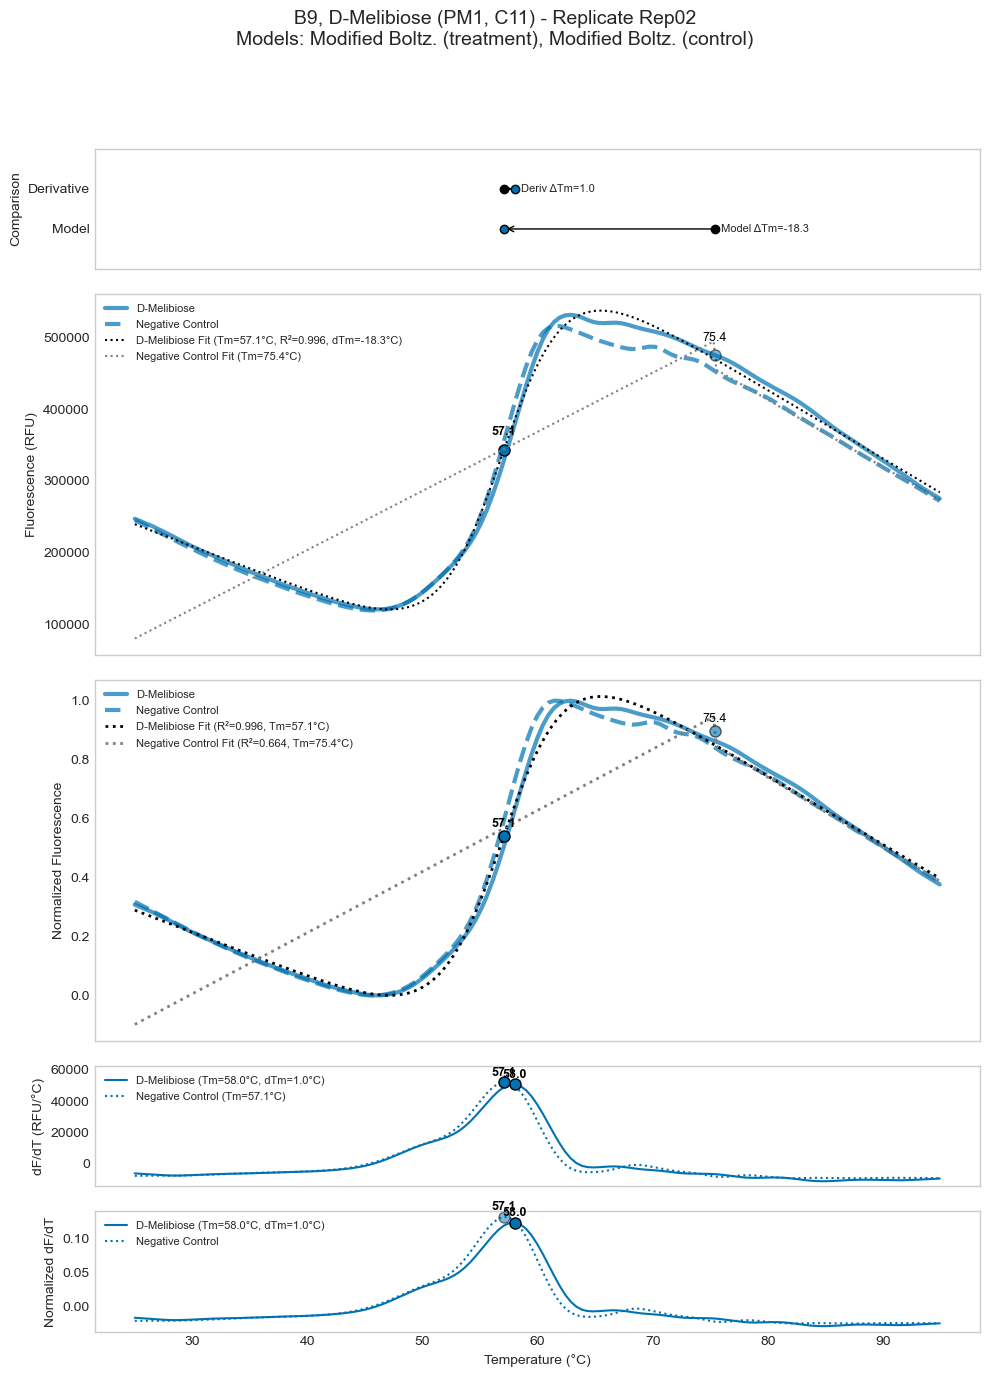

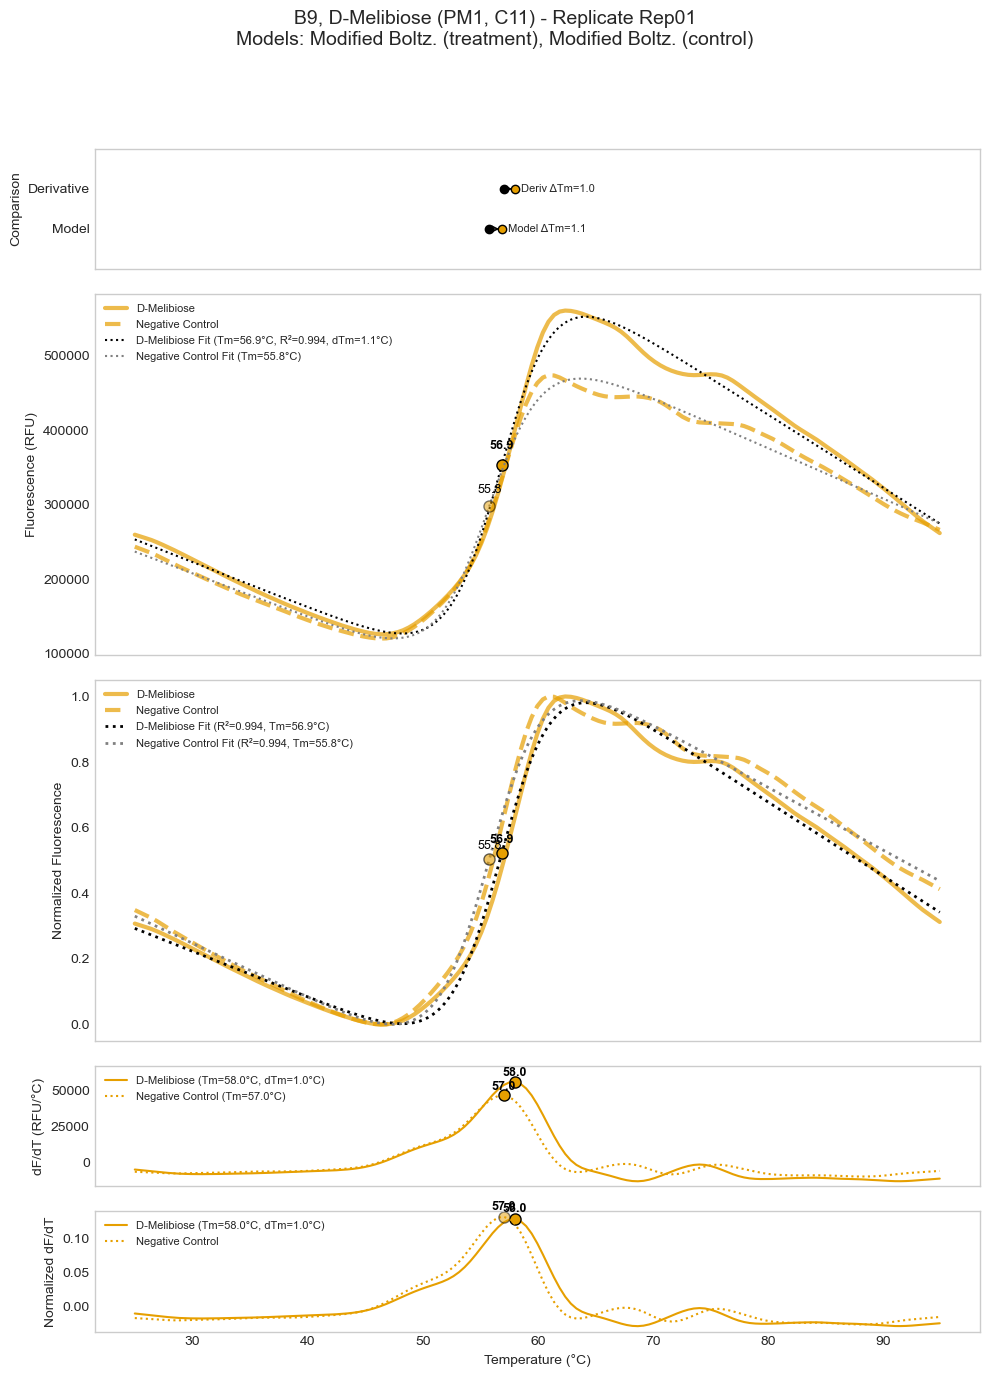

In [102]:
from dsf_analysis.core.data_loading import get_ligand_for_plate_well
from dsf_analysis.core.models import normalize_df, compute_derivative
from scipy.signal import find_peaks
from dsf_analysis.core.models import MODEL_PARAMS

treatment_well = "C11"
# Plot with negative control comparison
fig_with_neg = plot_replicates_with_comparison(
    protein=protein,
    plate=plate,
    treatment_well=treatment_well,
    neg_control_well="A01",
    raw_data_dfs=raw_data_dfs,
    candidate_models=["mB"],
    window_mode="full",
    window_sizes=[20, 30, 40],
    include_tmchange_subplot=True, 
    include_norm_subplot=True
)
plt.show()


reps are dict_keys(['Rep02', 'Rep01'])
Plotting: B9 | PM1 | A02
Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Figure saved as ./output_pngs/B9_PM1_A02_repRep02.png
Figure saved as ./output_pngs/B9_PM1_A02_repRep01.png


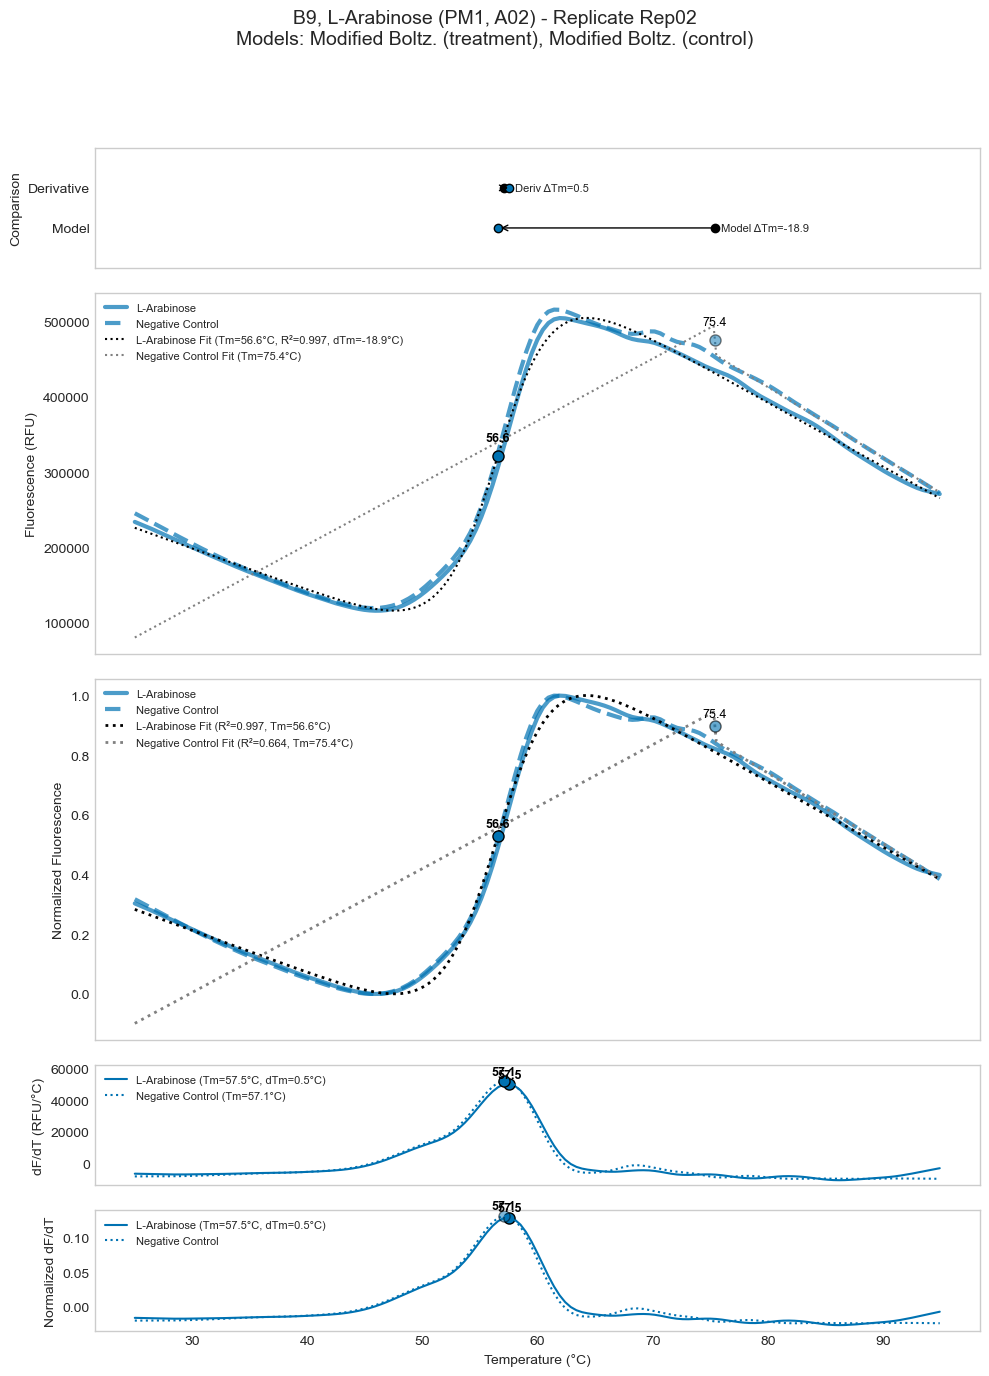

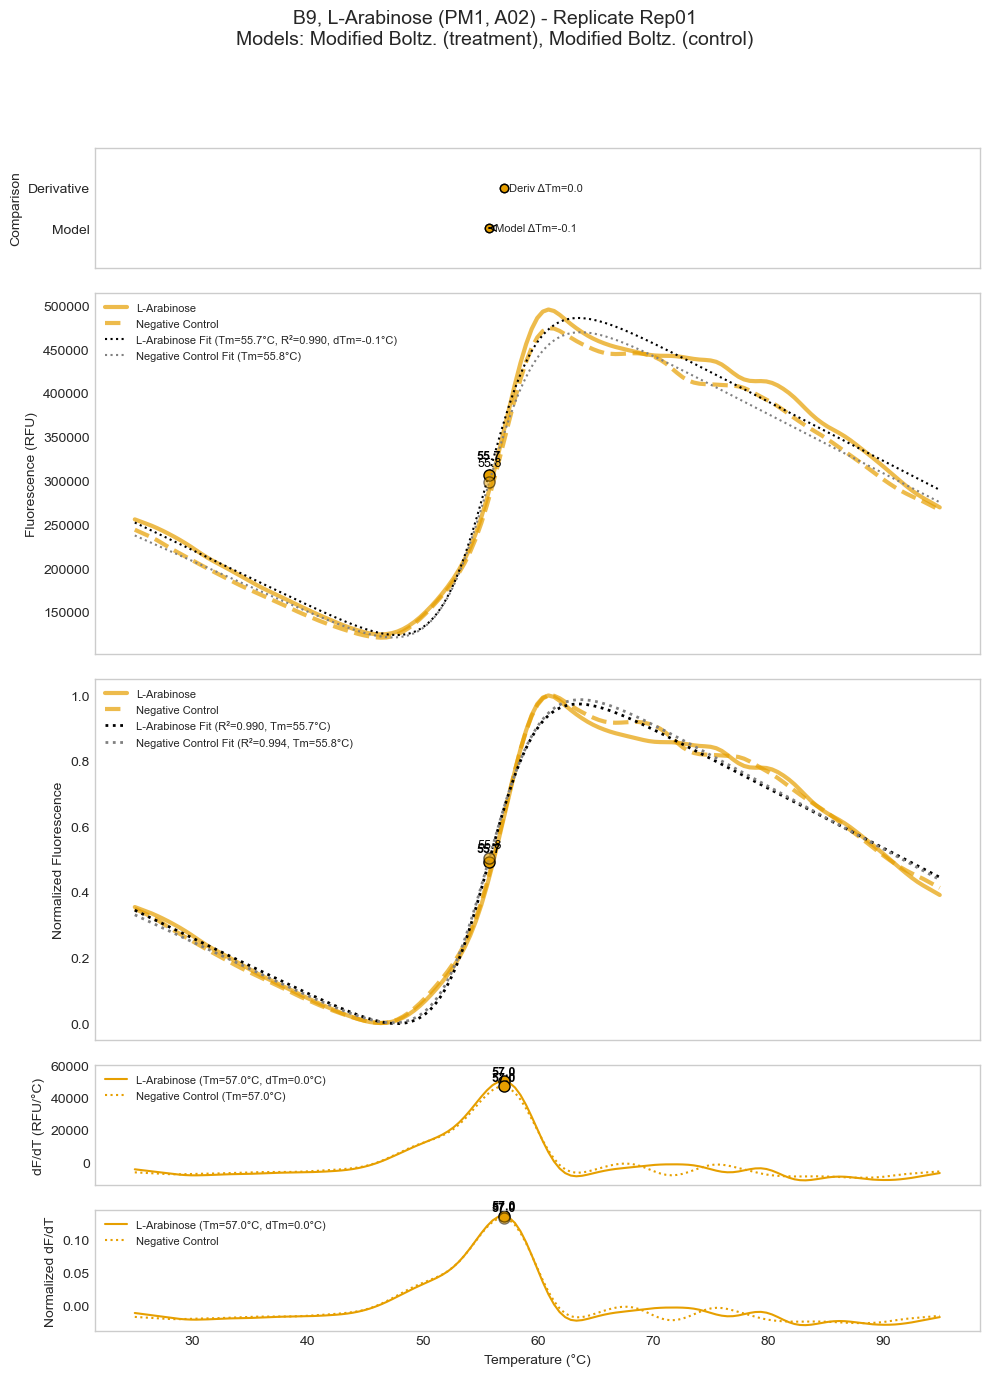

Plotting: B9 | PM1 | A03
Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Figure saved as ./output_pngs/B9_PM1_A03_repRep02.png
Figure saved as ./output_pngs/B9_PM1_A03_repRep01.png


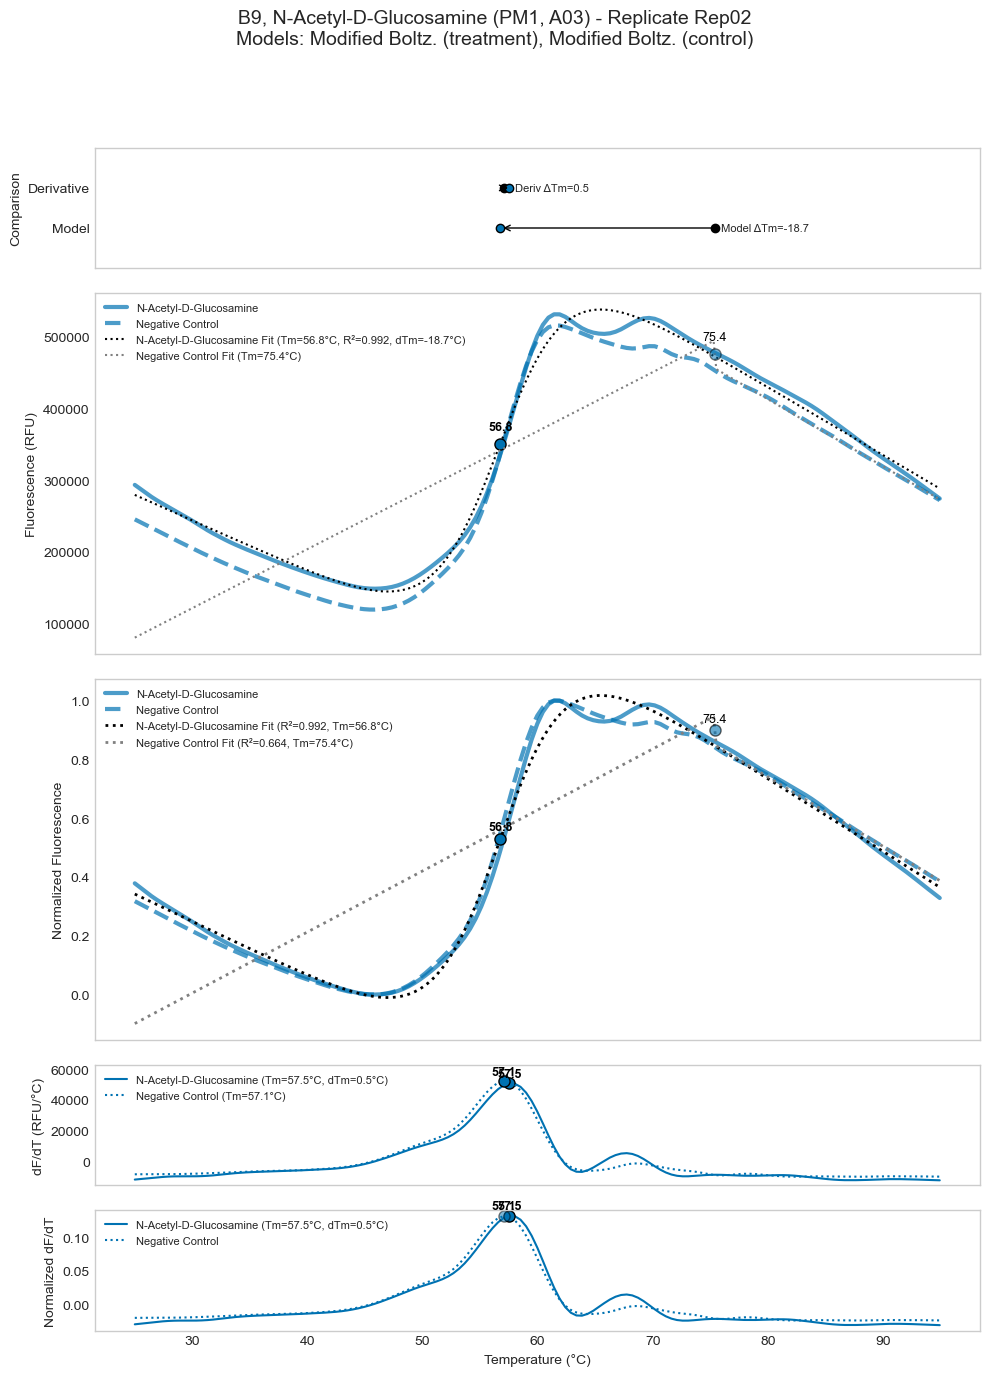

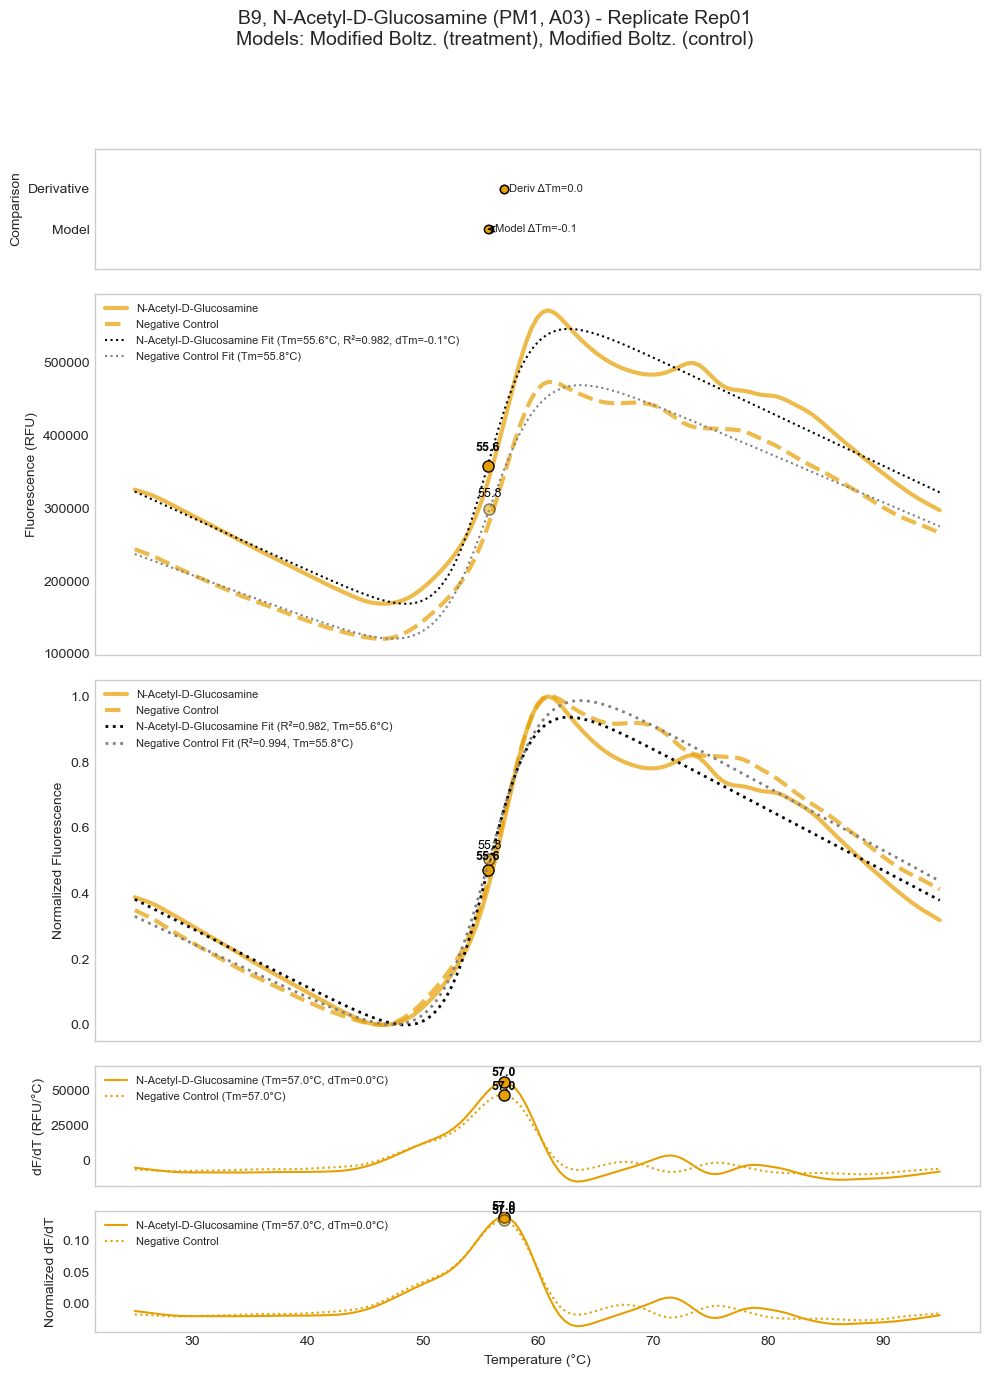

Plotting: B9 | PM1 | A04
Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Figure saved as ./output_pngs/B9_PM1_A04_repRep02.png
Figure saved as ./output_pngs/B9_PM1_A04_repRep01.png


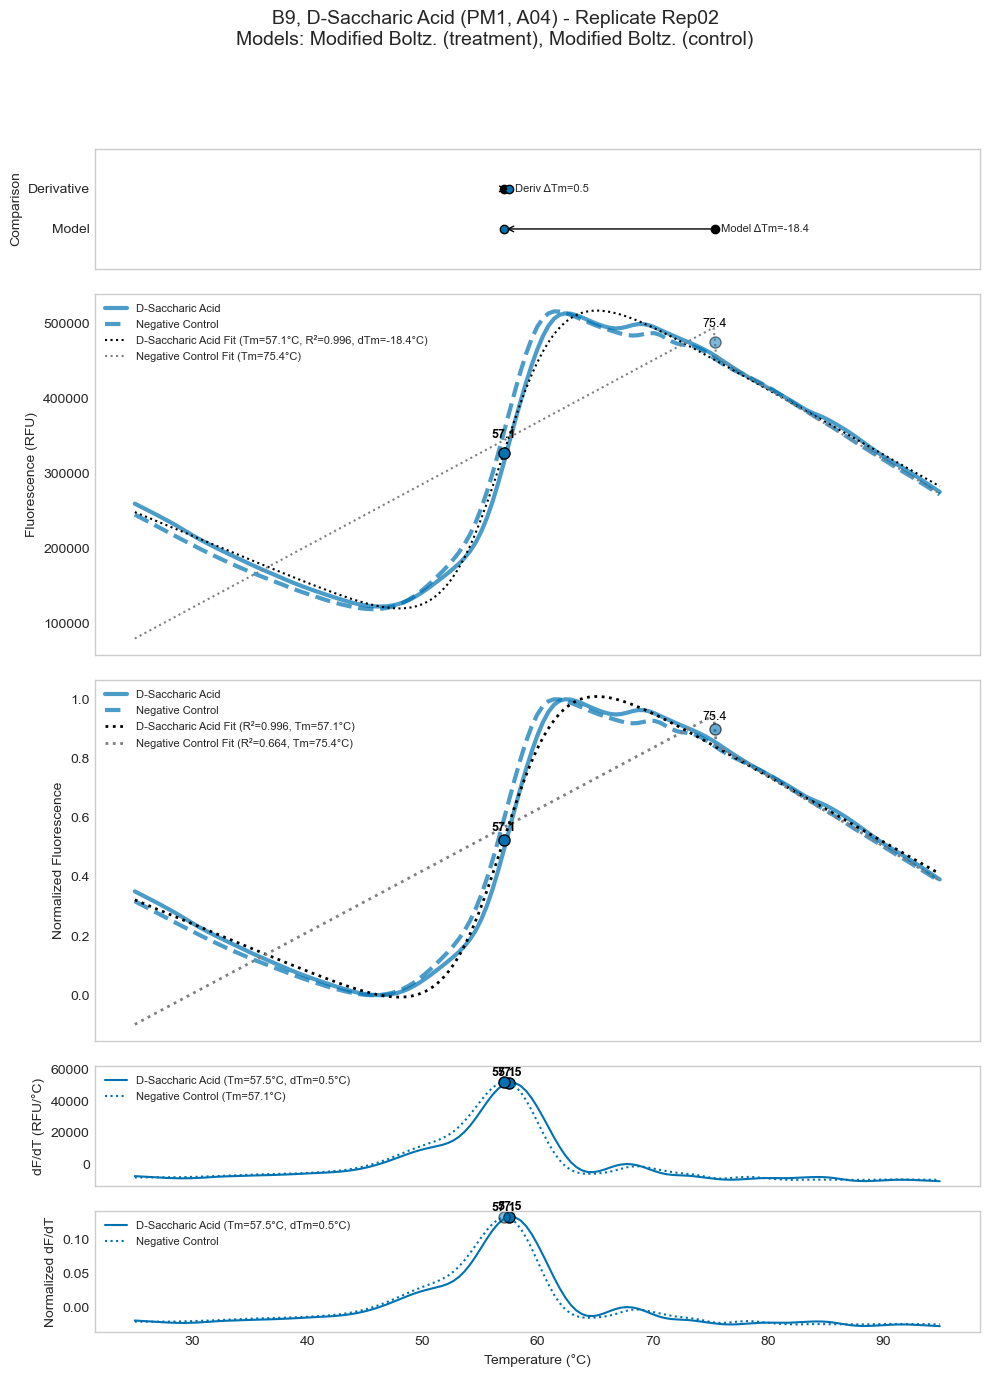

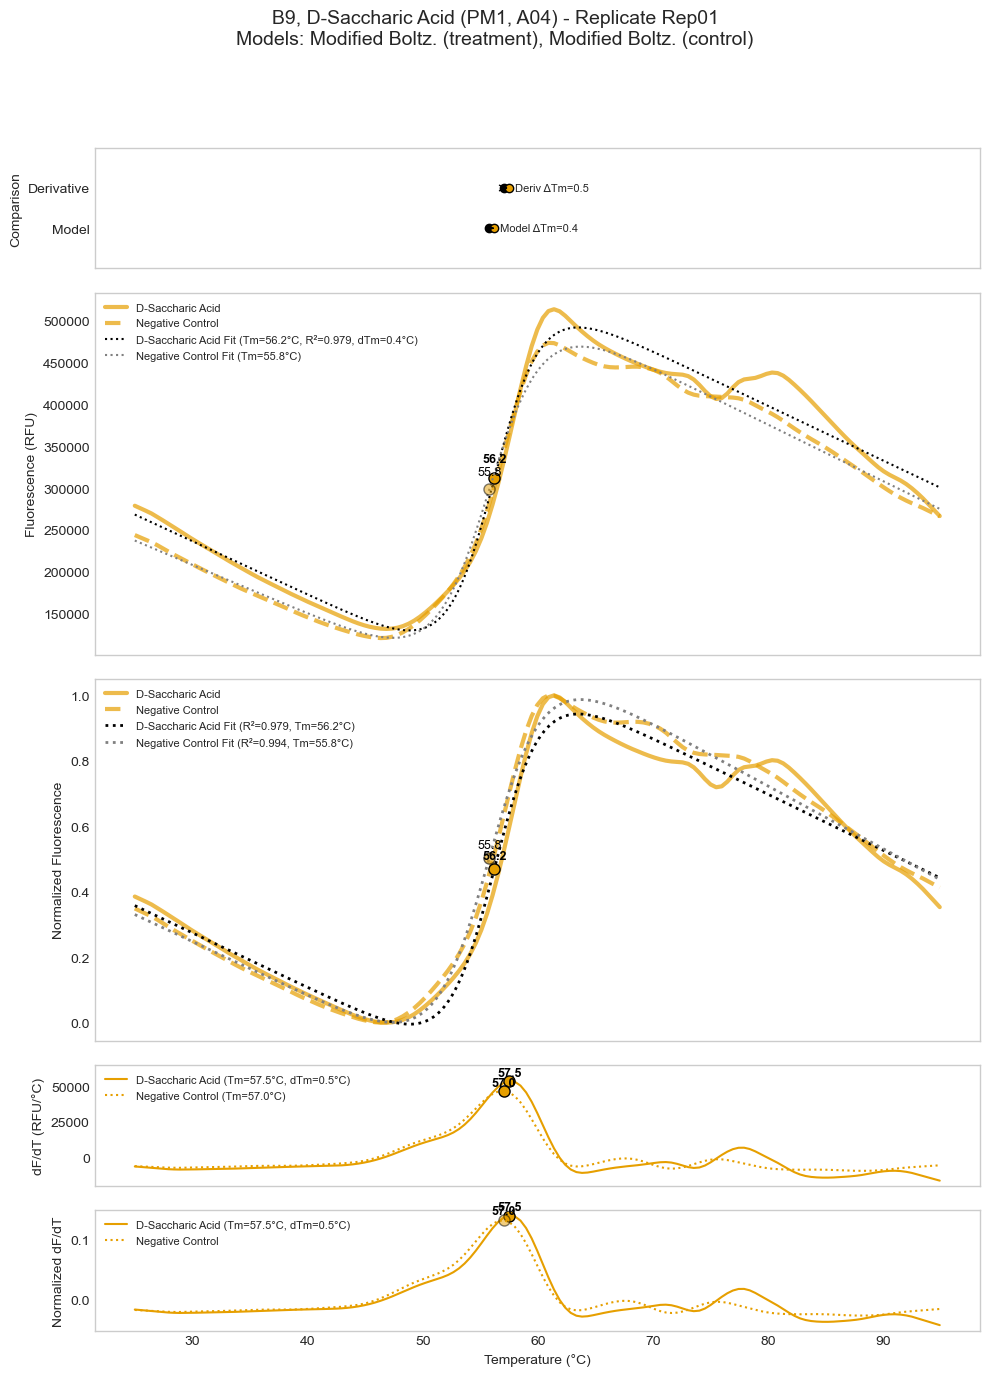

Plotting: B9 | PM1 | A05
Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



Figure saved as ./output_pngs/B9_PM1_A05_repRep02.png
Figure saved as ./output_pngs/B9_PM1_A05_repRep01.png


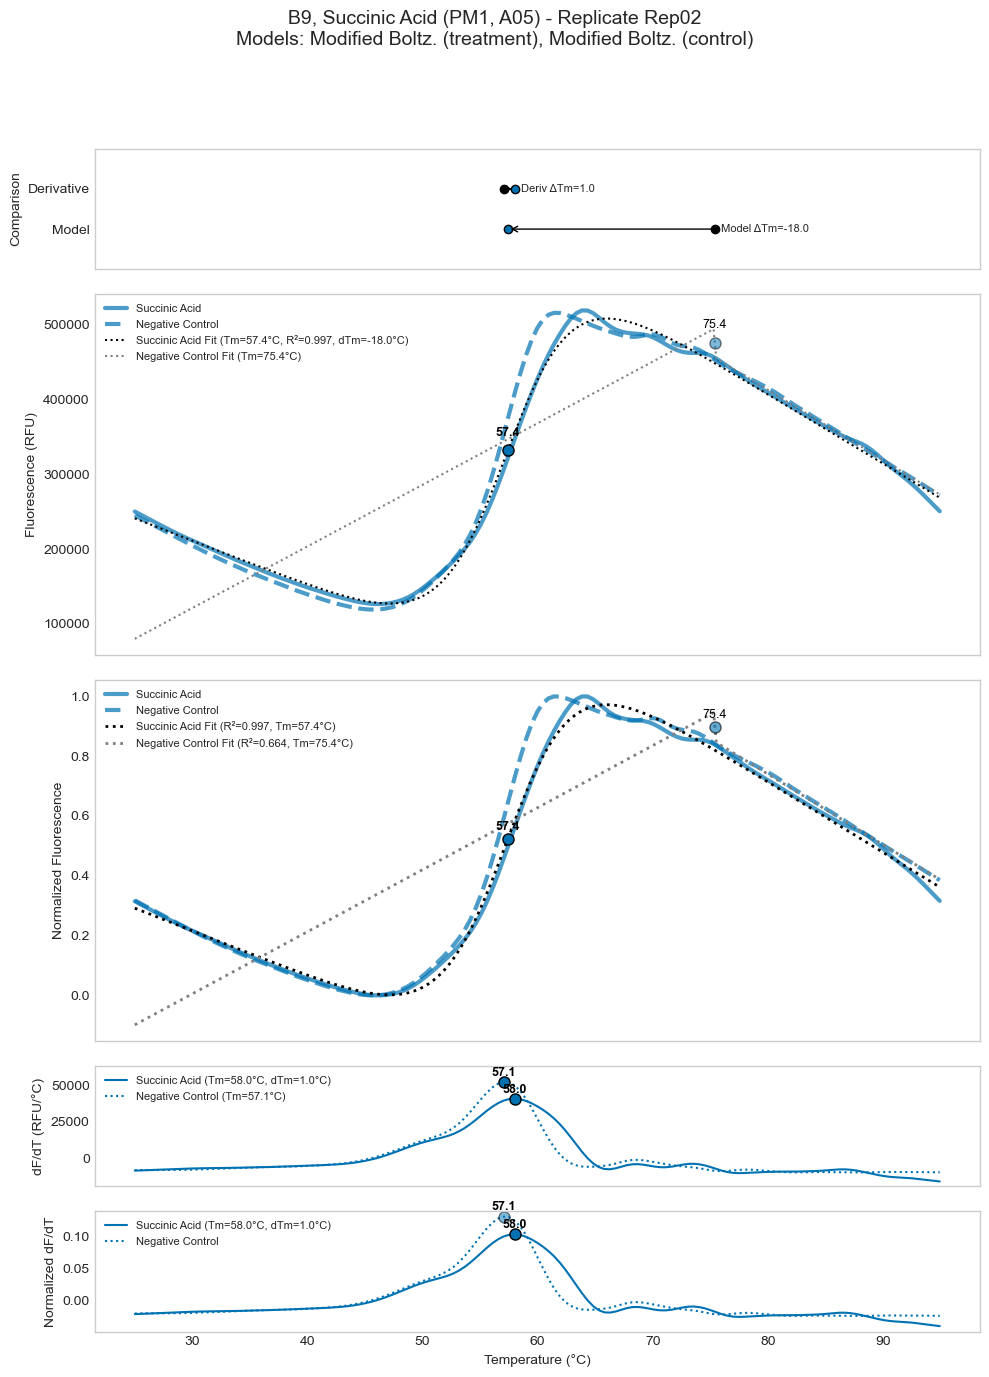

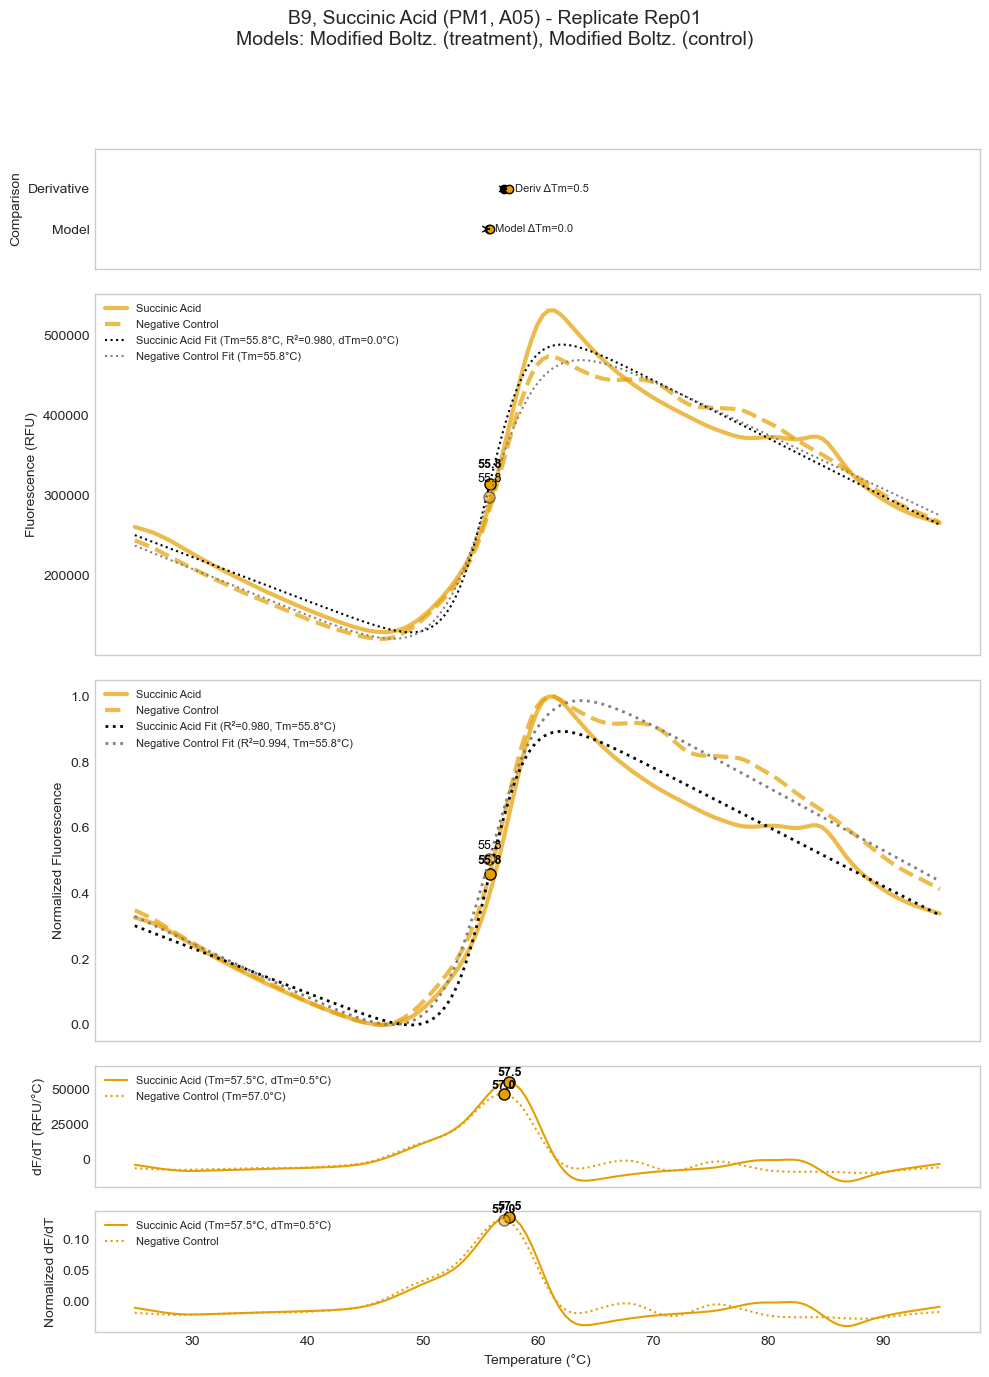

Plotting: B9 | PM1 | A06
Found replicates for B9 PM1: ['Rep02', 'Rep01']


/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp

/Users/u4855540/github-repositories/dsf-thermal-shift/dsf_analysis/core/models.py:127: RuntimeWarning:

overflow encountered in exp



KeyboardInterrupt: 

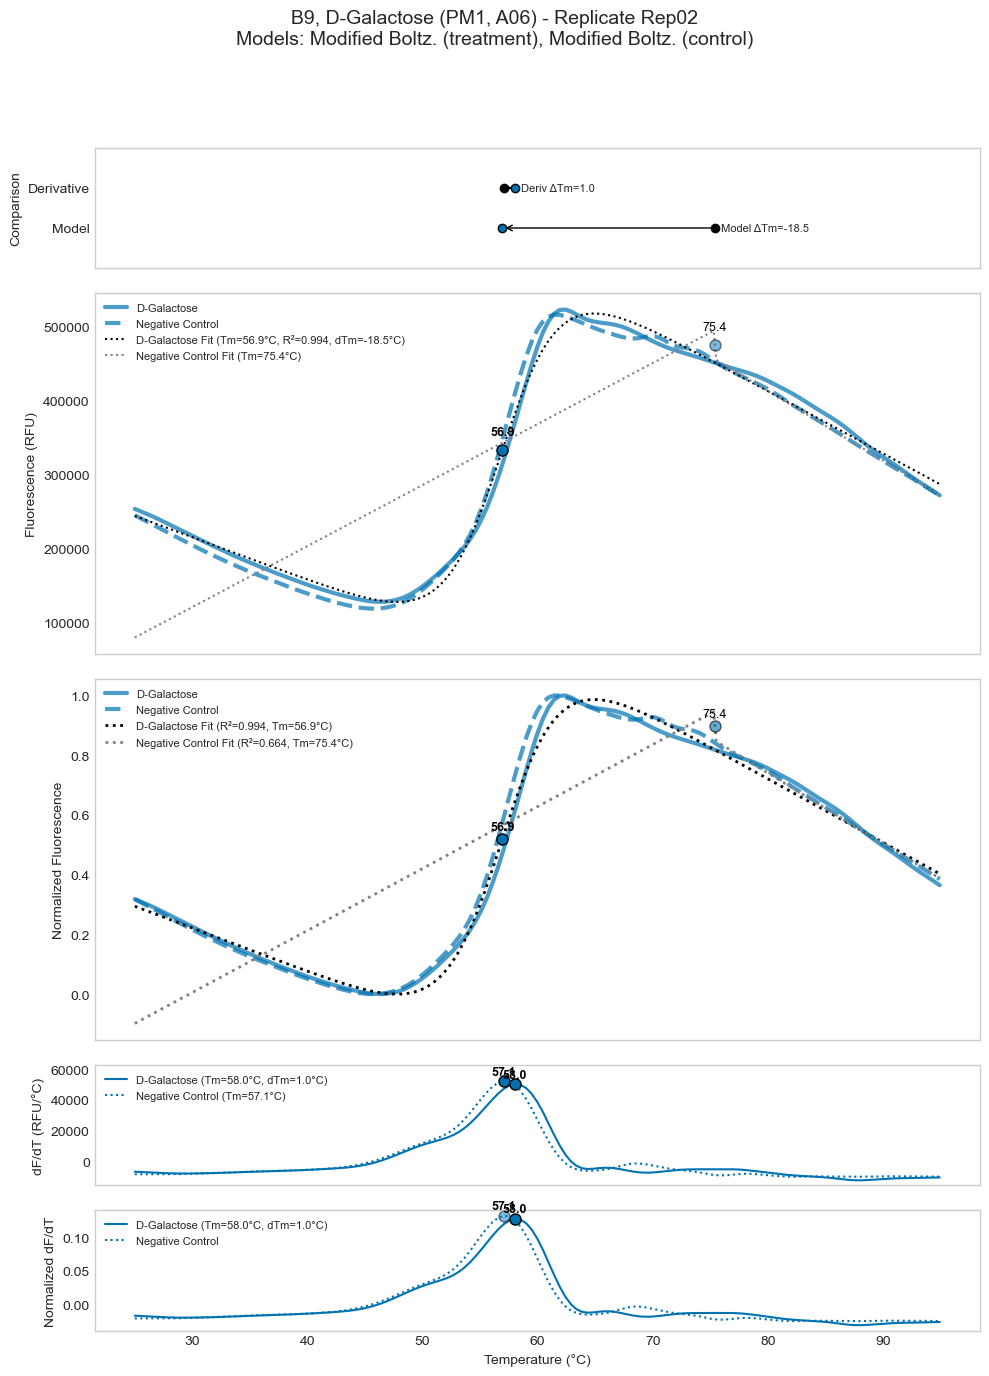

In [98]:

# Loop over all protein–plate–well combinations
for protein in raw_data_dfs:
    for plate in raw_data_dfs[protein]:
        reps = raw_data_dfs[protein][plate].keys()
        print(f"reps are {reps}")
        
        # Get all wells for first replicate (assumes same structure across reps)
        example_rep = next(iter(reps))
        wells = raw_data_dfs[protein][plate][example_rep].keys()

        # Loop through all wells, skipping control wells if needed
        for treatment_well in wells:
            if treatment_well == "A01":  # Skip if it's your standard negative control
                continue

            print(f"Plotting: {protein} | {plate} | {treatment_well}")
            fig = plot_replicates_with_comparison(
                protein=protein,
                plate=plate,
                treatment_well=treatment_well,
                neg_control_well="A01",  # or another control if appropriate
                raw_data_dfs=raw_data_dfs,
                candidate_models=["mB"],  # or other models
                window_mode="full",
                window_sizes=[40,60,80],
                include_tmchange_subplot=True,
                include_norm_subplot=True,
                separate_rep_figures=True,  # ✅ this is the key
                skip_fit=False, save_png=True
            )
            if fig is not None:
                # fig.tight_layout()
                plt.show()
            else:
                print("no fig")

In [82]:
# # Plot with chemical structure if SMILES is available
# if SMILES_AVAILABLE:
#     # Get ligand name
#     ligand = None
#     if 'Ligand' in df_raw.columns:
#         ligand = df_raw['Ligand'].iloc[0]
#     else:
#         from dsf_analysis.core.data_loading import get_ligand_for_plate_well
#         ligand = get_ligand_for_plate_well(raw_data_dfs, plate, treatment_well)
    
#     # Create a fit result with ligand information
#     best_fit_with_ligand = best_fit_all.copy()
#     best_fit_with_ligand['ligand'] = ligand
    
#     # Plot with structure
#     fig_with_structure = plot_dsf_curve_with_structure(
#         df_raw=df_raw,
#         best_fit=best_fit_with_ligand,
#         title=f"DSF Curve with Structure: {protein}, {plate}, {treatment_well}, {ligand}",
#         show_structure=True
#     )
#     plt.show()
    
#     # Create a grid of structures for all compounds
#     compounds = list(smiles_mapping.keys())[:9]  # Take first 9 compounds
#     fig_grid = create_structure_grid(compounds, ncols=3)
#     plt.suptitle("Chemical Structures of Compounds", fontsize=16)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()
# else:
#     print("SMILES visualization not available. Install RDKit to enable this feature.")

In [67]:
# Create an interactive heatmap
if len(master_df) > 0:
    # Filter data for a specific protein and plate
    protein_to_plot = protein
    plate_to_plot = plate
    
    df_subset = master_df[(master_df["protein"] == protein_to_plot) & 
                         (master_df["plate_ID"] == plate_to_plot)]
    
    if len(df_subset) > 0:
        # Create heatmap for Tm1
        fig_heatmap = create_interactive_heatmap(
            df=df_subset,
            x_col="ligand",
            y_col="well",
            value_col="Tm1",
            title=f"{protein_to_plot}, {plate_to_plot} - Tm1",
            sig_figs=2
        )
        fig_heatmap.show()
        
        # Create heatmap for dTm1 if available
        if "dTm1" in df_subset.columns:
            fig_heatmap_dtm = create_interactive_heatmap(
                df=df_subset,
                x_col="ligand",
                y_col="well",
                value_col="dTm1",
                title=f"{protein_to_plot}, {plate_to_plot} - ΔTm1",
                sig_figs=2
            )
            fig_heatmap_dtm.show()
    else:
        print(f"No data available for {protein_to_plot}, {plate_to_plot}")
else:
    print("No data available for heatmap visualization")

## Plotting Raw Data from All Plates

Let's create a function to plot raw data from all plates and proteins in the dataset.

In [ ]:
def plot_all_raw_data(raw_data_dfs, max_wells_per_plate=5):
    """Plot raw data from all plates and proteins."""
    for protein in raw_data_dfs:
        for plate in raw_data_dfs[protein]:
            print(f"Plotting {protein}, {plate}...")
            
            # Get the first replicate
            rep = list(raw_data_dfs[protein][plate].keys())[0]
            
            # Get wells to plot (limit to max_wells_per_plate)
            wells = list(raw_data_dfs[protein][plate][rep].keys())
            if len(wells) > max_wells_per_plate:
                # Always include A01 (negative control) and select others
                if "A01" in wells:
                    wells.remove("A01")
                    selected_wells = ["A01"] + wells[:max_wells_per_plate-1]
                else:
                    selected_wells = wells[:max_wells_per_plate]
            else:
                selected_wells = wells
            
            # Create figure
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), 
                                          gridspec_kw={'height_ratios': [3, 1]},
                                          sharex=True)
            
            # Set title
            fig.suptitle(f"{protein}, {plate}, {rep}", fontsize=16)
            
            # Plot each well
            for well in selected_wells:
                df = raw_data_dfs[protein][plate][rep][well]
                
                # Get ligand name if available
                ligand = "Unknown"
                if 'Ligand' in df.columns:
                    ligand = df['Ligand'].iloc[0]
                
                # Plot raw data
                ax1.plot(df["Temperature"], df["Fluorescence"], 'o-', 
                        alpha=0.7, label=f"{well} ({ligand})")
                
                # Calculate and plot derivative
                temp = df["Temperature"].values
                fluor = df["Fluorescence"].values
                deriv = np.gradient(fluor, temp)
                ax2.plot(temp, deriv, '-', alpha=0.7, label=f"{well}")
            
            # Set labels and legend
            ax1.set_ylabel("Fluorescence (RFU)")
            ax1.legend(fontsize=9, loc='upper left')
            
            ax2.set_xlabel("Temperature (°C)")
            ax2.set_ylabel("dF/dT (RFU/°C)")
            
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

# Plot raw data from all plates
plot_all_raw_data(raw_data_dfs)

## Tm Shift Plotting Examples

Finally, let's create plots specifically focused on thermal shift (ΔTm) data.

In [ ]:
def plot_tm_shifts(master_df, protein=None, plate=None):
    """Plot thermal shifts for specified protein and plate."""
    # Filter data
    if protein is not None and plate is not None:
        df_subset = master_df[(master_df["protein"] == protein) & 
                             (master_df["plate_ID"] == plate)]
    elif protein is not None:
        df_subset = master_df[master_df["protein"] == protein]
    elif plate is not None:
        df_subset = master_df[master_df["plate_ID"] == plate]
    else:
        df_subset = master_df
    
    # Check if we have dTm data
    if "dTm1" not in df_subset.columns or len(df_subset) == 0:
        print("No thermal shift data available for the selected protein/plate.")
        return
    
    # Create bar plot of dTm values
    plt.figure(figsize=(12, 6))
    
    # Sort by dTm1 value
    df_sorted = df_subset.sort_values("dTm1")
    
    # Create labels
    labels = [f"{row['ligand']} ({row['well']})" for _, row in df_sorted.iterrows()]
    
    # Plot bars
    bars = plt.bar(range(len(df_sorted)), df_sorted["dTm1"], 
                  color=["red" if x > 0 else "blue" for x in df_sorted["dTm1"]])
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., 
                height + 0.1 if height > 0 else height - 0.6,
                f"{df_sorted['dTm1'].iloc[i]:.1f}°C", 
                ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=8)
    
    # Set labels and title
    plt.xlabel("Compound")
    plt.ylabel("ΔTm (°C)")
    title = "Thermal Shifts (ΔTm)"
    if protein is not None:
        title += f" - {protein}"
    if plate is not None:
        title += f" - {plate}"
    plt.title(title)
    
    # Set x-ticks
    plt.xticks(range(len(df_sorted)), labels, rotation=90, fontsize=8)
    
    # Add horizontal line at y=0
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add grid
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create heatmap
    fig_heatmap = create_interactive_heatmap(
        df=df_subset,
        x_col="ligand",
        y_col="well",
        value_col="dTm1",
        title=f"Thermal Shifts (ΔTm) Heatmap",
        sig_figs=2
    )
    fig_heatmap.show()

# Plot thermal shifts for all data
if len(master_df) > 0 and "dTm1" in master_df.columns:
    # Plot for specific protein and plate
    plot_tm_shifts(master_df, protein=protein, plate=plate)
    
    # Plot for all data
    plot_tm_shifts(master_df)
else:
    print("No thermal shift data available.")

## Conclusion

This notebook has demonstrated the key features of the DSF Analysis package:

1. **Basic and Advanced Data Loading**: Loading DSF data with optional UniProt and SMILES integration
2. **Model Fitting**: Fitting various models to melting curves, with a focus on the modified Boltzmann model
3. **Visualization**: Creating static and interactive plots of raw data, model fits, and thermal shifts
4. **Chemical Structure Integration**: Visualizing chemical structures alongside DSF data (when RDKit is available)

The package provides a comprehensive set of tools for analyzing DSF data, from basic preprocessing to advanced visualization and integration with external databases. It is designed to be memory-efficient, feature-rich, and user-friendly.

For more information, please refer to the package documentation and example files.